In [1]:
import os
import glob
import pandas as pd

# Define the relativee path to your folder
folder_path = 'Traduction avis clients'

# Use glob to find every .xlsx file inside that folder
excel_files = glob.glob(os.path.join(folder_path, '*.xlsx'))

print(f"Found {len(excel_files)} Excel files. Starting the merge")

# Create an empty list to store our individual DataFrames
dataframes_list = []

# Loop through each file, read it, and add it to our list
for file in excel_files:
    try:
        # Read the Excel file
        temp_df = pd.read_excel(file)
        dataframes_list.append(temp_df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all 35 DataFrames into one master DataFrame
# ignore_index=True ensures our row numbers go from 0 to the very end smoothly
df_master = pd.concat(dataframes_list, ignore_index=True)

print(f"Merge completely successful! Total combined rows: {len(df_master)}")

# Display the first few rows and the column names to see what we are working with
print("\nColumn Names found in the merged dataset:")
print(df_master.columns.tolist())

print("\nFirst 3 rows of data:")
print(df_master.head(3))

Found 35 Excel files. Starting the merge
Merge completely successful! Total combined rows: 34435

Column Names found in the merged dataset:
['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']

First 3 rows of data:
   note             auteur                                               avis  \
0   4.0  audurier-c-136272  La personne au téléphone était Clair et sympat...   
1   4.0      paul-a-122970  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2   1.0        kitty-38517  Assureur à fuir, n assure pas ses responsabili...   

              assureur produit   type date_publication    date_exp  \
0  L'olivier Assurance    auto  train       06/10/2021  01/10/2021   
1           APRIL Moto    moto  train       09/07/2021  01/07/2021   
2            SwissLife     vie  train       15/10/2020  01/10/2020   

                                             avis_en avis_cor avis_cor_en  
0  The person on the phone 

In [2]:
# Suppression des doublons exacts
df = df_master.drop_duplicates()

# Conversion des colonnes de dates au format "datetime"
# On utilise errors='coerce' pour transformer les erreurs de format en "NaT" (valeur nulle)
df['date_publication'] = pd.to_datetime(df['date_publication'], format='%d/%m/%Y', errors='coerce')
df['date_exp'] = pd.to_datetime(df['date_exp'], format='%d/%m/%Y', errors='coerce')

# Vérifier s'il y a des valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum())

Valeurs manquantes par colonne :
 note                10330
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            33995
avis_cor_en         33999
dtype: int64


C:\Users\natha\AppData\Local\Temp\ipykernel_7044\3285174359.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_publication'] = pd.to_datetime(df['date_publication'], format='%d/%m/%Y', errors='coerce')
C:\Users\natha\AppData\Local\Temp\ipykernel_7044\3285174359.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_exp'] = pd.to_datetime(df['date_exp'], format='%d/%m/%Y', errors='coerce')


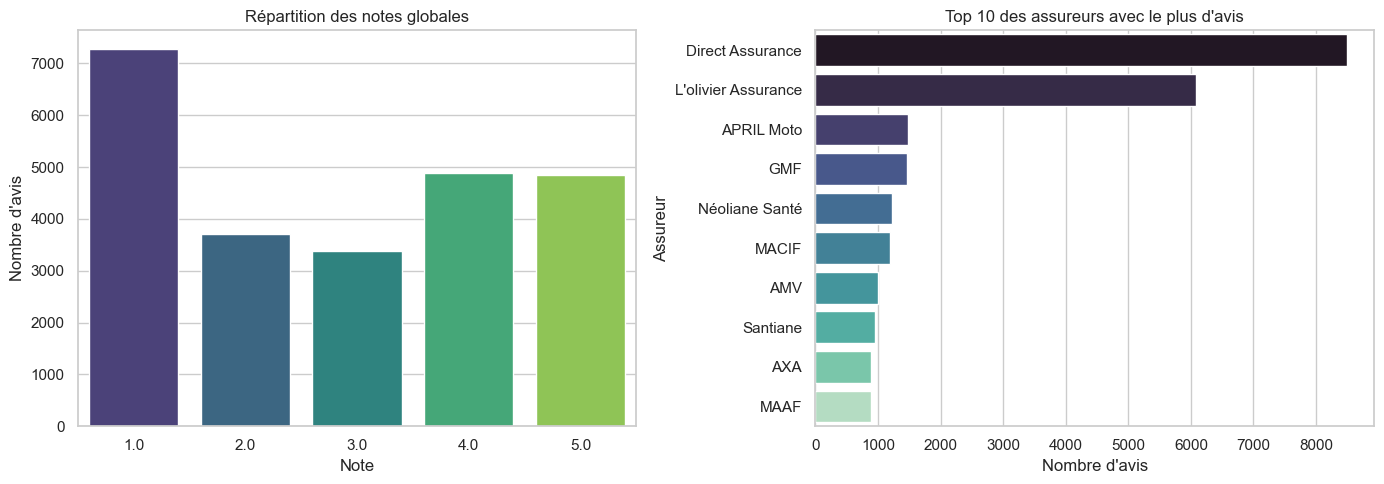

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Graphique 1 : Répartition des notes (1 à 5)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='note', palette='viridis')
plt.title('Répartition des notes globales')
plt.xlabel('Note')
plt.ylabel("Nombre d'avis")

# Graphique 2 : Nombre d'avis par assureur (Top 10)
plt.subplot(1, 2, 2)
top_assureurs = df['assureur'].value_counts().head(10)
sns.barplot(y=top_assureurs.index, x=top_assureurs.values, palette='mako')
plt.title('Top 10 des assureurs avec le plus d\'avis')
plt.xlabel("Nombre d'avis")
plt.ylabel('Assureur')

plt.tight_layout()
plt.show()

Plotting Top 15 Words (Unigrams)...


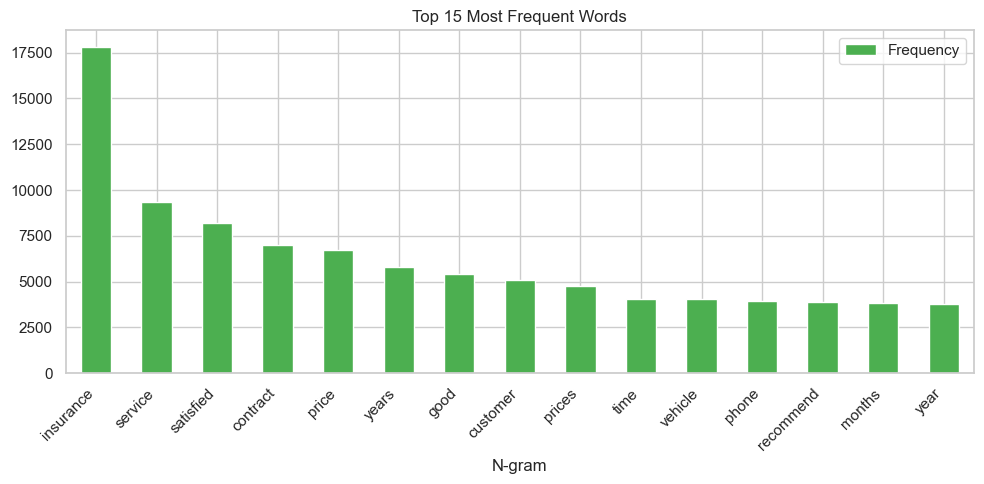

Plotting Top 15 Pairs of Words (Bigrams)...


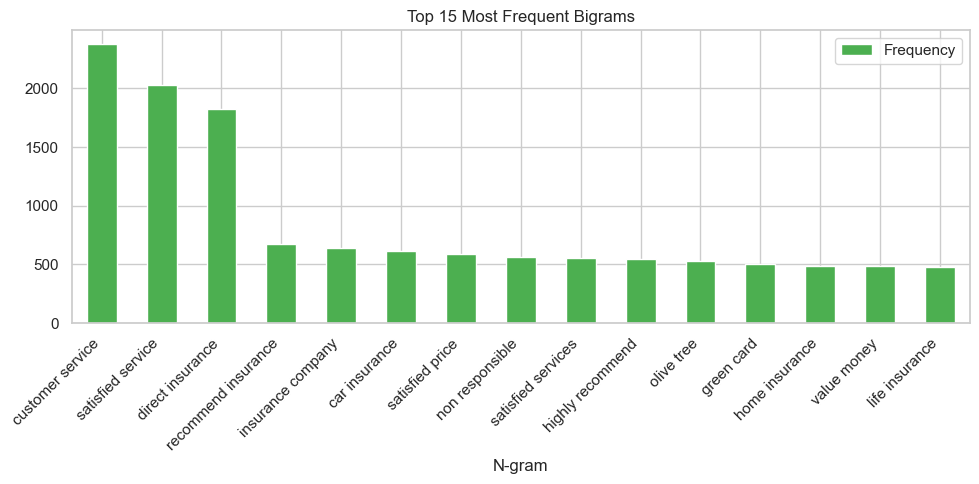

In [4]:
## Basic Cleaning & N-Gram Visualization

import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Drop any rows where the text is completely missing
df_clean = df_master.dropna(subset=['avis_en']).copy()

def plot_ngrams(corpus, n, title, top_k=15):
    # n=1 is unigrams (single words), n=2 is bigrams (two words)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    
    df_freq = pd.DataFrame(words_freq, columns=['N-gram', 'Frequency'])
    df_freq.plot(kind='bar', x='N-gram', y='Frequency', title=title, figsize=(10, 5), color='#4CAF50')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("Plotting Top 15 Words (Unigrams)...")
plot_ngrams(df_clean['avis_en'], 1, "Top 15 Most Frequent Words")

print("Plotting Top 15 Pairs of Words (Bigrams)...")
plot_ngrams(df_clean['avis_en'], 2, "Top 15 Most Frequent Bigrams")

In [5]:
!pip install pyspellchecker

In [6]:
import re
import pandas as pd
from spellchecker import SpellChecker
from tqdm import tqdm

# Initialize tqdm for pandas
tqdm.pandas()

print("Loading English spelling dictionary from pyspellchecker")
spell_en = SpellChecker(language='en')

def correct_english_spelling(text):
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    words = spell_en.split_words(text)
    misspelled = spell_en.unknown(words)
    
    corrected_text = text
    for word in misspelled:
        correction = spell_en.correction(word)
        
        if correction and correction != word:
            corrected_text = re.sub(rf'\b{re.escape(word)}\b', correction, corrected_text, flags=re.IGNORECASE)
            
    return corrected_text

print("Applying spelling correction to the first 100 English rows")
df_clean['avis_cor_en'] = df_clean['avis_en'].head(100).progress_apply(correct_english_spelling)

print("\nExample Comparison")
print("Original English:", df_clean['avis_en'].iloc[2])
print("Corrected English:", df_clean['avis_cor_en'].iloc[2])

Loading English spelling dictionary from pyspellchecker
Applying spelling correction to the first 100 English rows


100%|██████████| 100/100 [00:13<00:00,  7.56it/s]


Example Comparison
Original English: Insurer to flee, does not ensure its responsibilities! His insurance agent (SLR FINANCE) from Nice to make false contracts, no support, nothing, forced to make a lawsuit !!
 I will rot them on the web !!
Corrected English: Insurer to flee, does not ensure its responsibilities! His insurance agent (sir FINANCE) from Nice to make false contracts, no support, nothing, forced to make a lawsuit !!
 I will rot them on the web !!


In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

print("Preparing text for Topic Modeling...")
# We use the English reviews ('avis_en') and remove standard stop words
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df_clean['avis_en'].dropna())

print("Training LDA Model to find 5 core topics...")
# We set n_components=5 to find 5 distinct topics
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

print("\n--- Discovered Topics ---")
# Display the top 10 words for each topic
for index, topic in enumerate(lda_model.components_):
    print(f"Topic #{index + 1}:")
    # Get the top 10 most heavily weighted words for this topic
    top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(" ".join(top_words))
    print("-" * 20)

Preparing text for Topic Modeling...
Training LDA Model to find 5 core topics...

--- Discovered Topics ---
Topic #1:
maif disaster euros responsible accident expert car vehicle years insurance
--------------------
Topic #2:
sent service time email phone file months mutual insurance contract
--------------------
Topic #3:
satisfied year years customer service home prices direct price insurance
--------------------
Topic #4:
simple insurance price fast recommend thank prices good service satisfied
--------------------
Topic #5:
online site simple subscription loading insurance contract quote satisfied price
--------------------


In [8]:
import nltk
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

# Download the tokenizer package
nltk.download('punkt')
nltk.download('punkt_tab')

print("Tokenizing the reviews for Word2Vec...")
# Word2Vec expects a list of lists (sentences broken into words)
# This might take a minute or two for 34,000 rows!
sentences = [word_tokenize(str(text).lower()) for text in df_clean['avis_en'].dropna()]

print("Training the Word2Vec model...")
# vector_size=100 means each word becomes a 100-dimension vector
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4)

print("Word2Vec Training Complete!\n")

# --- Testing Cosine Distance (Worth 1 Rubric Point) ---
test_word = "insurance"
print(f"Top 5 words most mathematically similar to '{test_word}':")

# .most_similar automatically uses Cosine Distance behind the scenes!
similar_words = w2v_model.wv.most_similar(test_word, topn=5)
for word, similarity_score in similar_words:
    print(f"- {word} (Similarity: {similarity_score:.4f})")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\natha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\natha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Tokenizing the reviews for Word2Vec...
Training the Word2Vec model...
Word2Vec Training Complete!

Top 5 words most mathematically similar to 'insurance':
- assurance (Similarity: 0.7258)
- assurances (Similarity: 0.6749)
- debits (Similarity: 0.6245)
- debit (Similarity: 0.6202)
- insurer (Similarity: 0.6126)


Preparing top 100 words for Matplotlib visualization


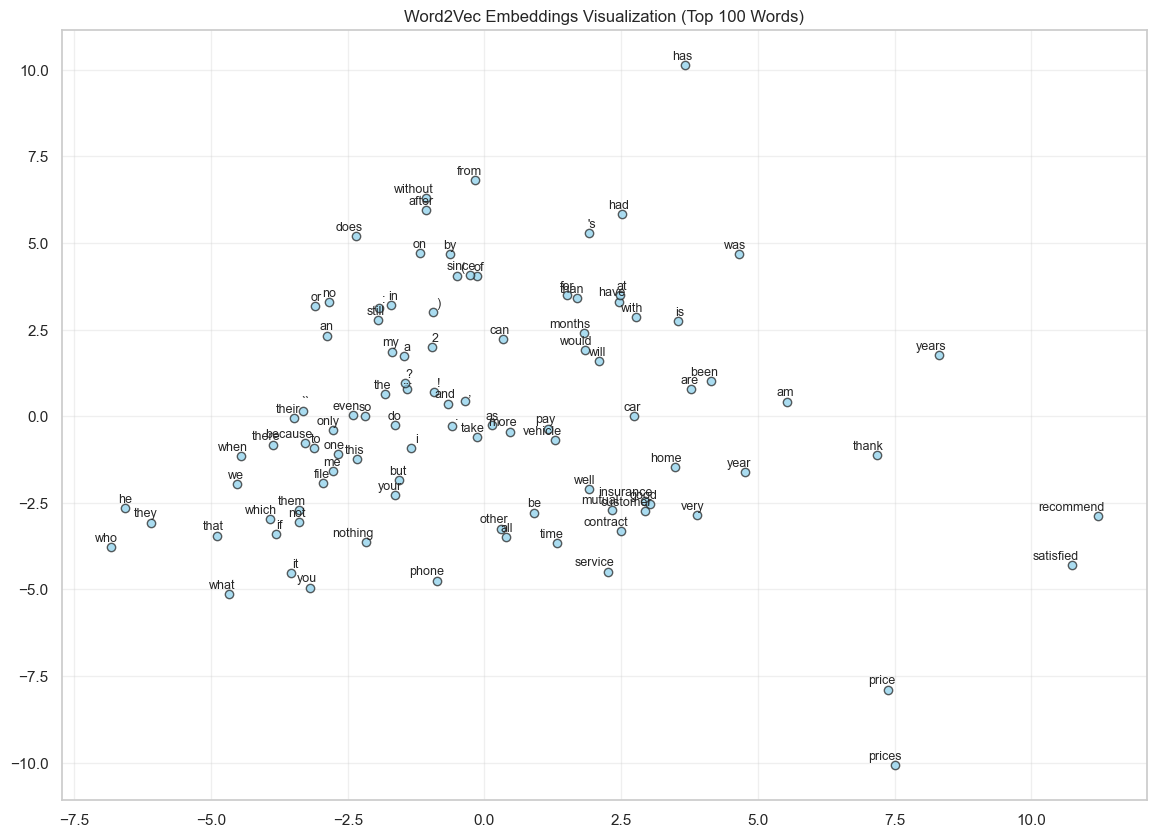

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("Preparing top 100 words for Matplotlib visualization")

# Extract the top 100 most frequent words and their vectors
words_to_plot = list(w2v_model.wv.index_to_key)[:100]
vectors = np.array([w2v_model.wv[word] for word in words_to_plot])

# Compress from 100 dimensions down to 2
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create the scatter plot
plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='skyblue', edgecolors='k', alpha=0.7)

# Add the word labels to each dot
for i, word in enumerate(words_to_plot):
    plt.annotate(word, 
                 xy=(vectors_2d[i, 0], vectors_2d[i, 1]), 
                 xytext=(5, 2), 
                 textcoords='offset points', 
                 ha='right', 
                 va='bottom',
                 fontsize=9)

plt.title("Word2Vec Embeddings Visualization (Top 100 Words)")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
import os
import torch
from torch.utils.tensorboard import SummaryWriter

print("Exporting top 1000 embeddings to TensorBoard")

# Create a folder for our logs
log_folder = "runs_word2vec"
os.makedirs(log_folder, exist_ok=True)

# Initialize the TensorBoard writer
writer = SummaryWriter(log_folder)

# Extract 1000 words this time for a richer interactive experience
tb_words = list(w2v_model.wv.index_to_key)[:1000]
tb_vectors = np.array([w2v_model.wv[word] for word in tb_words])

# Add the embeddings to TensorBoard
writer.add_embedding(torch.tensor(tb_vectors), metadata=tb_words, tag="Word2Vec_Reviews")
writer.close()

print("Export complete")

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\natha\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.